# Klasterisasi dan Ekonometrika Panel-Spasial Sistem Pangan ASEAN
### RASIO 10.0 — Padjadjaran Statistics Olympiad

**Unit analisis:** 44 negara Asia-Pasifik (10 di antaranya ASEAN, menjadi fokus penafsiran)
**Rentang waktu:** 1961–2024 (64 tahun) · **Bentuk data:** panel seimbang 44 × 64 = 2.816 observasi
**Sumber:** Our World in Data — *CO2 and Greenhouse Gas Emissions* (Global Carbon Budget; Jones dkk.)

| Peran | Variabel | Makna dalam sistem pangan | Satuan |
|---|---|---|---|
| Y | `luc_pc` | CO₂ alih guna lahan — tekanan konversi hutan menjadi lahan pangan | t/kapita |
| X1 | `ch4_pc` | Metana — sawah tergenang dan ternak ruminansia | t CO₂e/kapita |
| X2 | `n2o_pc` | Dinitrogen oksida — intensitas pemupukan nitrogen | t CO₂e/kapita |
| X3 | `co2_pc` | CO₂ energi — mekanisasi, rantai dingin, pengangkutan | t/kapita |

**Pertanyaan penelitian.** Apakah intensifikasi pertanian (pupuk dan sawah) menahan atau justru
mendorong perluasan lahan di Asia, dan seberapa besar tekanan itu melimpah melintasi batas negara?

**Mengapa sampelnya 44 negara, bukan 10.** Dengan hanya 10 negara ASEAN, Moran's I tidak
signifikan pada seluruh spesifikasi yang diuji (inverse-distance, KNN, aras, log) — nilai
harapannya sendiri sudah −0,111 dan kuasa ujinya terlalu rendah. Uji pada Bagian 13 menunjukkan
tipologi ASEAN **tidak berubah** ketika sampel diperluas (ARI = 1,000 terhadap sampel Asia
Monsun-19), sehingga perluasan ini menjaga kesahihan statistik tanpa menggeser cerita ASEAN.

**Berkas pendamping:** `panel_asia_1961_2024.csv`, `potret_2015_2024.csv`,
`fitur_lintasan_negara.csv`, `koordinat_negara.csv`, `W_knn*_asia44.csv`

## 0. Persiapan

In [5]:
import warnings, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                   QuantileTransformer, PowerTransformer)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

warnings.filterwarnings('ignore')
RS = 42; np.random.seed(RS)
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi':110, 'savefig.bbox':'tight', 'font.size':9})
HIJAU, BATA, PASIR, ABU = '#2F7D6E', '#C0392B', '#D9B26F', '#8896A0'

DIR = 'C:/Uner/Lomba/Rasio/2026/Penyisihan/RASIO_Analisis Spasial Panel'          # arahkan ke folder berisi berkas CSV
os.makedirs('gambar', exist_ok=True)

# Seluruh prosedur spasial ditulis ulang dengan numpy agar notebook ini berjalan
# tanpa libpysal/spreg. Bila paket itu terpasang, Bagian 14 memuat sel pembanding.

## 1. Data dan Pemeriksaan Keseimbangan Panel

In [6]:
panel  = pd.read_csv(f'{DIR}/panel_asia_1961_2024.csv')
potret = pd.read_csv(f'{DIR}/potret_2015_2024.csv', index_col=0)
fitur  = pd.read_csv(f'{DIR}/fitur_lintasan_negara.csv', index_col=0)
koord  = pd.read_csv(f'{DIR}/koordinat_negara.csv')

NEG    = sorted(panel.country.unique()); N = len(NEG); T = panel.year.nunique()
ASEAN  = koord[koord.is_asean == 1].country.tolist()
MONSUN = koord[koord.is_monsun == 1].country.tolist()
V      = ['luc_pc','ch4_pc','n2o_pc','co2_pc']
LAB    = {'luc_pc':'CO2 lahan','ch4_pc':'Metana','n2o_pc':'N2O','co2_pc':'CO2 energi'}
Y_, X_ = 'l_luc_pc', ['l_ch4_pc','l_n2o_pc','l_co2_pc']
NAMA_X = ['log Metana/kap','log N2O/kap','log CO2 energi/kap']

print(f'negara {N} | tahun {T} | observasi {len(panel)} (harapan {N*T})')
print('rumpang :', panel[V].isna().sum().sum())
print('ASEAN   :', ', '.join(ASEAN))
display(panel.head())

negara 44 | tahun 64 | observasi 2816 (harapan 2816)
rumpang : 0
ASEAN   : Brunei, Cambodia, Indonesia, Laos, Malaysia, Myanmar, Philippines, Singapore, Thailand, Vietnam


,country,iso_code,year,is_asean,is_monsun,lat,lon,populasi,luc_pc,ch4_pc,n2o_pc,co2_pc,l_luc_pc,l_ch4_pc,l_n2o_pc,l_co2_pc
0,Afghanistan,AFG,1961,0,0,34.5553,69.2075,9214082.0,1.585,0.948,0.317,0.053,0.949726,0.666803,0.275356,0.051643
1,Afghanistan,AFG,1962,0,0,34.5553,69.2075,9404410.0,1.405,0.949,0.307,0.073,0.877550,0.667316,0.267734,0.070458
2,Afghanistan,AFG,1963,0,0,34.5553,69.2075,9604491.0,1.317,0.955,0.306,0.074,0.840273,0.670390,0.266969,0.071390
3,Afghanistan,AFG,1964,0,0,34.5553,69.2075,9814317.0,1.011,0.949,0.306,0.085,0.698632,0.667316,0.266969,0.081580
4,Afghanistan,AFG,1965,0,0,34.5553,69.2075,10036003.0,1.024,0.948,0.307,0.100,0.705076,0.666803,0.267734,0.095310


## 2. Analisis Data Eksploratif Panel

Langkah pertama yang khas panel: memisahkan ragam **antar-negara** dari ragam **dalam-negara**.
Pangsa antar yang tinggi berarti struktur utama data bersifat lintang, sehingga klaster berbasis
aras dapat dibenarkan — tetapi dimensi waktu tetap wajib diuji secara terpisah (Bagian 3).

In [7]:
baris = []
for v in V:
    lv = 'l_' + v
    mu = panel.groupby('country')[lv].transform('mean')
    antar  = np.var(panel.groupby('country')[lv].mean(), ddof=1)
    dalam  = np.var(panel[lv] - mu, ddof=1)
    baris.append({'variabel':LAB[v], 'ragam antar':antar, 'ragam dalam':dalam,
                  'pangsa antar':100*antar/(antar+dalam)})
display(pd.DataFrame(baris).round(3))

,variabel,ragam antar,ragam dalam,pangsa antar
0,CO2 lahan,0.462,0.148,75.788
1,Metana,0.514,0.083,86.084
2,N2O,0.133,0.010,92.840
3,CO2 energi,0.933,0.153,85.894


,count,mean,std,min,25%,50%,75%,max
luc_pc,44.0,0.691,1.322,-2.279,0.007,0.084,1.228,4.354
ch4_pc,44.0,2.122,2.578,0.240,0.638,0.980,1.998,11.077
n2o_pc,44.0,0.492,0.786,0.095,0.185,0.275,0.335,4.237
co2_pc,44.0,6.893,8.146,0.263,1.460,3.559,8.702,37.856


,skewness,kurtosis,menceng kuat
CO2 lahan,1.141,1.251,True
Metana,2.046,3.551,True
N2O,3.698,13.971,True
CO2 energi,1.938,4.059,True


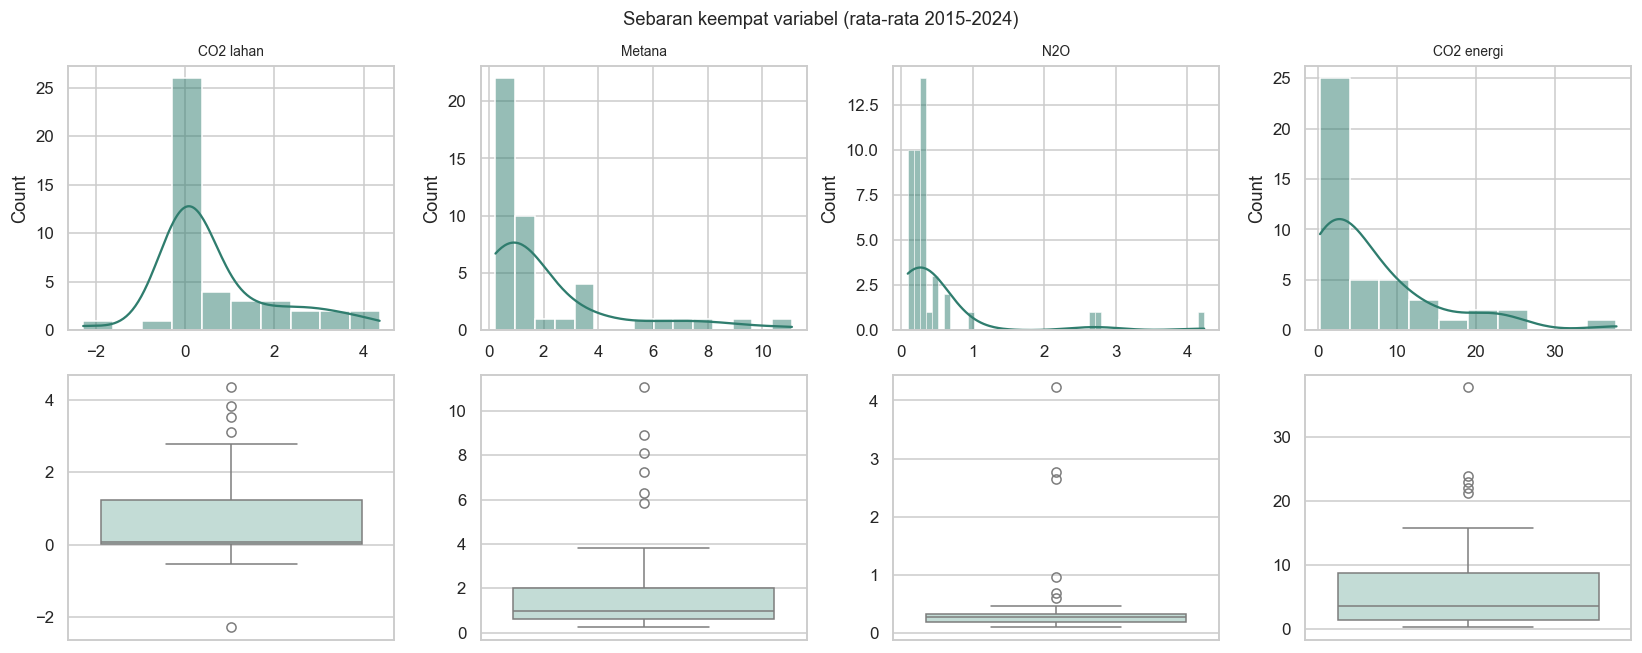

In [8]:
ring = pd.DataFrame({'skewness':potret[V].skew(), 'kurtosis':potret[V].kurtosis()})
ring['menceng kuat'] = ring.skewness.abs() > 1
ring.index = [LAB[v] for v in V]
display(potret[V].describe().T.round(3)); display(ring.round(3))

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for i, v in enumerate(V):
    sns.histplot(potret[v], kde=True, ax=axes[0,i], color=HIJAU)
    axes[0,i].set_title(LAB[v], fontsize=9); axes[0,i].set_xlabel('')
    sns.boxplot(y=potret[v], ax=axes[1,i], color='#BFE0D8'); axes[1,i].set_ylabel('')
fig.suptitle('Sebaran keempat variabel (rata-rata 2015-2024)', fontsize=12)
plt.tight_layout(); plt.show()

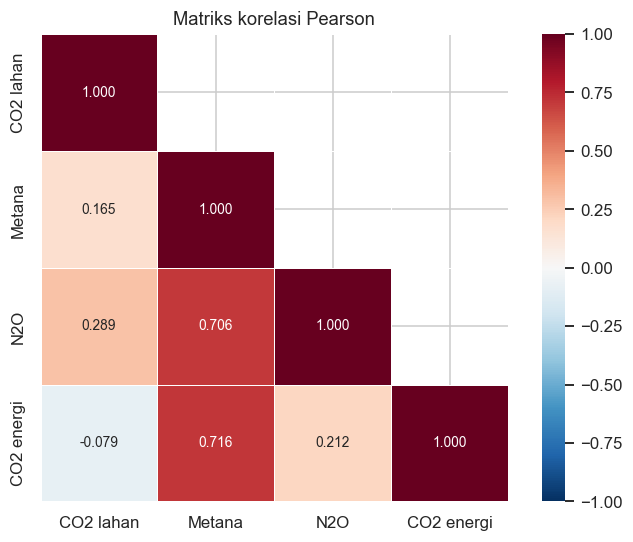

,variabel,VIF
0,CO2 lahan,1.26
1,Metana,3.53
2,N2O,2.11
3,CO2 energi,2.37


In [9]:
cor = potret[V].corr()
cor.index = cor.columns = [LAB[v] for v in V]
plt.figure(figsize=(6.5,5))
sns.heatmap(cor, mask=np.triu(np.ones_like(cor, dtype=bool), k=1), annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title('Matriks korelasi Pearson'); plt.tight_layout(); plt.show()

def vif(X):
    X = np.column_stack([np.ones(len(X)), X]); out = []
    for j in range(1, X.shape[1]):
        idx = [i for i in range(X.shape[1]) if i != j]
        b, *_ = np.linalg.lstsq(X[:,idx], X[:,j], rcond=None)
        r2 = 1 - ((X[:,j]-X[:,idx]@b)**2).sum()/((X[:,j]-X[:,j].mean())**2).sum()
        out.append(1/(1-r2) if r2 < 1 else np.inf)
    return out

Xv = np.column_stack([np.log1p(potret[v].clip(lower=0)) for v in V])
display(pd.DataFrame({'variabel':[LAB[v] for v in V], 'VIF':np.round(vif(Xv),2)}))

## 3. Tiga Ruang Fitur untuk Klasterisasi Panel

Inilah inti penyesuaian terhadap data panel. Mengklaster satu tahun saja membuang 63 tahun
informasi. Karena itu dibandingkan tiga cara merepresentasikan tiap negara:

| Ruang | Isi | Dimensi |
|---|---|---|
| **POTRET** | aras rata-rata 2015–2024 | 4 |
| **LINTASAN** | aras + tren log + volatilitas + pergeseran jangka panjang, tiap variabel | 16 |
| **SERI** | seluruh lintasan 64 tahun yang dibakukan per negara | 256 |

Kesepakatan antarruang diukur dengan ARI pada Bagian 6. Nilai yang rendah membuktikan dimensi
waktu memuat informasi yang tak tertangkap potret.

In [10]:
X_snap = np.column_stack([np.log1p(potret[v].clip(lower=0)) for v in V])
kol_traj = [c for c in fitur.columns if '__' in c]
X_traj = fitur.loc[NEG, kol_traj].values
piv_l = {v: panel.pivot(index='country', columns='year', values='l_'+v).loc[NEG].values for v in V}
X_seri = np.column_stack([(piv_l[v]-piv_l[v].mean(1,keepdims=True)) /
                          (piv_l[v].std(1,keepdims=True)+1e-9) for v in V])
RUANG = {'POTRET':X_snap, 'LINTASAN':X_traj, 'SERI':X_seri}
for k, v in RUANG.items(): print(f'{k:<9}{v.shape}')

POTRET   (44, 4)
LINTASAN (44, 16)
SERI     (44, 256)


## 4. Pencarian Konfigurasi Klaster

Dijelajahi **4 skema praproses × 3 ruang fitur × 3 proyeksi × 4 nilai k × 6 algoritma**.
Dua syarat kelayakan disaring lebih dulu — klaster terbesar maksimal 70% unit dan setiap klaster
minimal 2 anggota. Salah satu algoritma, **WardSpasial**, adalah aglomeratif dengan matriks
konektivitas ketetanggaan sehingga klaster dipaksa bersambung secara geografis; ini varian yang
khusus sesuai untuk data spasial.

In [11]:
W5 = pd.read_csv(f'{DIR}/W_knn5_asia44.csv', index_col=0).loc[NEG, NEG].values
CONN = ((W5 > 0) | (W5.T > 0)).astype(int)

SKEMA_PRA = {'Standard':StandardScaler(), 'Robust':RobustScaler(),
             'YeoJohnson':PowerTransformer('yeo-johnson', standardize=True),
             'Quantile':QuantileTransformer(output_distribution='normal',
                                            n_quantiles=min(30,N), random_state=RS)}
MAKS_PANGSA, MIN_ANGGOTA = 0.70, 2
def layak(lab, n):
    u = np.bincount(lab); return (u.max()/n <= MAKS_PANGSA) and (u.min() >= MIN_ANGGOTA)

def algoritma(nama, k, Z):
    if nama=='KMeans':      return KMeans(k, n_init=100, random_state=RS).fit_predict(Z)
    if nama=='GMM':         return GaussianMixture(k, covariance_type='full', n_init=20,
                                                   random_state=RS).fit_predict(Z)
    if nama=='Ward':        return AgglomerativeClustering(k, linkage='ward').fit_predict(Z)
    if nama=='Average':     return AgglomerativeClustering(k, linkage='average').fit_predict(Z)
    if nama=='Spectral':    return SpectralClustering(k, random_state=RS,
                                  affinity='nearest_neighbors', n_neighbors=6).fit_predict(Z)
    if nama=='WardSpasial': return AgglomerativeClustering(k, linkage='ward',
                                  connectivity=CONN).fit_predict(Z)

hasil = []
for nr, Xr in RUANG.items():
    for np_, pre in SKEMA_PRA.items():
        M = pre.fit_transform(Xr)
        for proy in ['fitur','PCA2','PCA3']:
            Z = M if proy=='fitur' else PCA(int(proy[-1]), random_state=RS).fit_transform(M)
            for k in range(3,7):
                for a in ['KMeans','GMM','Ward','Average','Spectral','WardSpasial']:
                    try: lab = algoritma(a,k,Z)
                    except Exception: continue
                    if len(set(lab)) < k or not layak(lab,N): continue
                    hasil.append({'ruang_fitur':nr,'praproses':np_,'proyeksi':proy,'k':k,
                                  'algoritma':a,'silhouette':silhouette_score(Z,lab),
                                  'davies_bouldin':davies_bouldin_score(Z,lab),
                                  'calinski':calinski_harabasz_score(Z,lab)})
grid = pd.DataFrame(hasil)
grid['skor'] = (grid.silhouette.rank(ascending=False) + grid.davies_bouldin.rank()
                + grid.calinski.rank(ascending=False))
grid = grid.sort_values('skor').reset_index(drop=True)
print(f'konfigurasi lolos kelayakan: {len(grid)}')
display(grid.head(10).round(4))
print('\nTerbaik per ruang fitur:')
for nr in RUANG:
    b = grid[grid.ruang_fitur==nr].iloc[0]
    print(f'  {nr:<9}{b.praproses:<11}{b.proyeksi:<6}k={b.k} {b.algoritma:<12}sil={b.silhouette:.4f}')

konfigurasi lolos kelayakan: 543


,ruang_fitur,praproses,proyeksi,k,algoritma,silhouette,davies_bouldin,calinski,skor
0,POTRET,Standard,PCA2,5,KMeans,0.5336,0.5279,94.0998,16.0
1,POTRET,Robust,PCA2,5,Ward,0.5015,0.5569,180.7249,35.5
2,POTRET,Robust,PCA2,5,KMeans,0.5015,0.5569,180.7249,35.5
3,POTRET,Standard,PCA2,5,Ward,0.5064,0.5498,90.5701,43.0
4,POTRET,Standard,PCA2,4,Average,0.5275,0.5613,68.4963,45.5
5,POTRET,Standard,PCA2,4,Ward,0.5275,0.5613,68.4963,45.5
6,SERI,Standard,PCA2,6,KMeans,0.5209,0.5728,69.2231,48.0
7,POTRET,YeoJohnson,PCA2,5,GMM,0.5205,0.5192,58.8241,54.5
8,POTRET,YeoJohnson,PCA2,5,Ward,0.5205,0.5192,58.8241,54.5
9,SERI,Standard,PCA2,6,Average,0.5190,0.5612,66.1372,55.0



Terbaik per ruang fitur:
  POTRET   Standard   PCA2  k=5 KMeans      sil=0.5336
  LINTASAN Standard   PCA2  k=6 KMeans      sil=0.4345
  SERI     Standard   PCA2  k=6 KMeans      sil=0.5209


## 5. Klaster Final dan Profilnya

In [12]:
M  = StandardScaler().fit_transform(X_snap)
P2 = PCA(2, random_state=RS).fit(M); Z = P2.transform(M); K = 5
lab = KMeans(K, n_init=300, random_state=RS).fit_predict(Z)
print(f'PC1 {P2.explained_variance_ratio_[0]:.1%} + PC2 {P2.explained_variance_ratio_[1]:.1%}'
      f' = {P2.explained_variance_ratio_.sum():.1%} | silhouette {silhouette_score(Z,lab):.4f}')
display(pd.DataFrame(P2.components_.T, index=[LAB[v] for v in V],
                     columns=['PC1','PC2']).round(3))

prof = pd.DataFrame(M, index=NEG, columns=[LAB[v] for v in V]); prof['k'] = lab
pz = prof.groupby('k').mean()

def beri_nama(r):
    if r['CO2 lahan']>0.7 and r['N2O']>1.5: return 'Peternakan Ekstensif'
    if r['CO2 lahan']>0.7:                  return 'Frontier Konversi Lahan'
    if r['CO2 energi']>0.7:                 return 'Petro-Ekonomi Pengimpor Pangan'
    if r['CO2 energi']>-0.2:                return 'Industri Mapan Rendah-Lahan'
    return 'Padat Penduduk Intensitas Rendah'
NAMA = {k: beri_nama(pz.loc[k]) for k in pz.index}
potret['klaster'] = lab; potret['nama_klaster'] = [NAMA[l] for l in lab]

tampil = pz.copy(); tampil.index = [f'{k} — {NAMA[k]}' for k in pz.index]
tampil['n'] = [int((lab==k).sum()) for k in pz.index]
display(tampil.round(2))
for k in sorted(pz.index, key=lambda kk: -pz.loc[kk,'CO2 lahan']):
    a = [c for c,l in zip(NEG,lab) if l==k]; asn = [c for c in a if c in ASEAN]
    print(f'\n[{k}] {NAMA[k]} (n={len(a)})\n   {", ".join(a)}')
    print(f'   ASEAN: {", ".join(asn) if asn else "-"}')

PC1 56.6% + PC2 28.3% = 84.9% | silhouette 0.5336


,PC1,PC2
CO2 lahan,0.217,0.832
Metana,0.622,-0.125
N2O,0.553,0.253
CO2 energi,0.510,-0.477


,CO2 lahan,Metana,N2O,CO2 energi,n
0 — Industri Mapan Rendah-Lahan,-0.64,-0.30,-0.21,0.31,12
1 — Peternakan Ekstensif,1.42,2.02,2.72,1.11,4
2 — Frontier Konversi Lahan,1.59,-0.31,-0.24,-0.50,8
3 — Petro-Ekonomi Pengimpor Pangan,-0.72,1.35,0.09,1.56,6
4 — Padat Penduduk Intensitas Rendah,-0.47,-0.72,-0.50,-0.96,14



[2] Frontier Konversi Lahan (n=8)
   Cambodia, Indonesia, Laos, Malaysia, Myanmar, Papua New Guinea, Thailand, Vietnam
   ASEAN: Cambodia, Indonesia, Laos, Malaysia, Myanmar, Thailand, Vietnam

[1] Peternakan Ekstensif (n=4)
   Australia, Brunei, Mongolia, New Zealand
   ASEAN: Brunei

[4] Padat Penduduk Intensitas Rendah (n=14)
   Afghanistan, Armenia, Bangladesh, India, Jordan, Kyrgyzstan, Nepal, North Korea, Pakistan, Philippines, Sri Lanka, Syria, Tajikistan, Yemen
   ASEAN: Philippines

[0] Industri Mapan Rendah-Lahan (n=12)
   Azerbaijan, China, Georgia, Iran, Iraq, Israel, Japan, Lebanon, Singapore, South Korea, Turkey, Uzbekistan
   ASEAN: Singapore

[3] Petro-Ekonomi Pengimpor Pangan (n=6)
   Kazakhstan, Kuwait, Qatar, Saudi Arabia, Turkmenistan, United Arab Emirates
   ASEAN: -


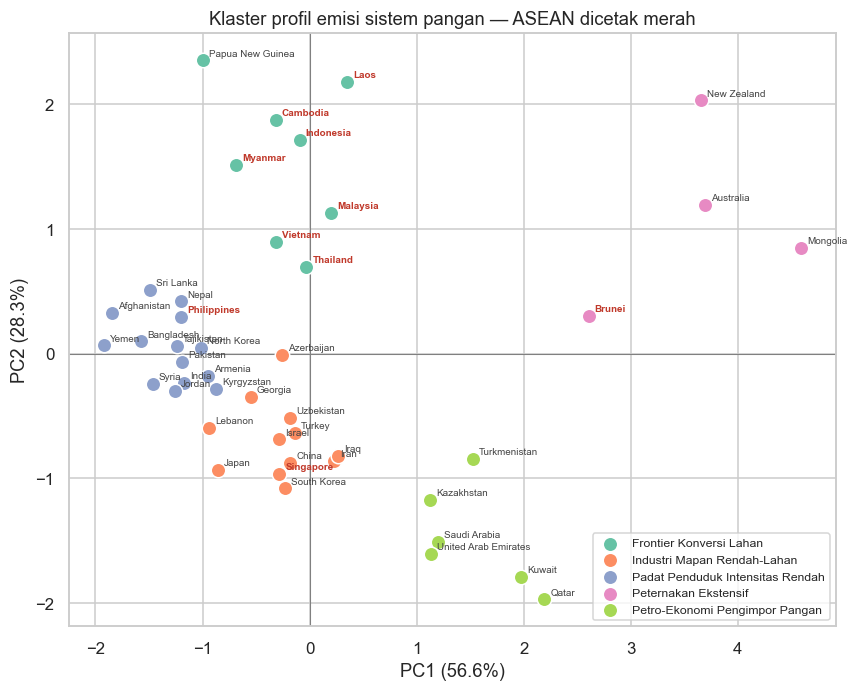

In [13]:
warna = dict(zip(sorted(set(NAMA.values())), sns.color_palette('Set2', len(set(NAMA.values())))))
fig, ax = plt.subplots(figsize=(9,7))
for nmk in sorted(set(NAMA.values())):
    m = np.array([NAMA[l]==nmk for l in lab])
    ax.scatter(Z[m,0], Z[m,1], s=90, color=warna[nmk], edgecolor='white', label=nmk, zorder=3)
for i,c in enumerate(NEG):
    ax.annotate(c, (Z[i,0],Z[i,1]), fontsize=6.5, xytext=(4,3), textcoords='offset points',
                weight='bold' if c in ASEAN else 'normal',
                color=BATA if c in ASEAN else '#444')
ax.axhline(0, color='grey', lw=.7); ax.axvline(0, color='grey', lw=.7)
ax.set(xlabel=f'PC1 ({P2.explained_variance_ratio_[0]:.1%})',
       ylabel=f'PC2 ({P2.explained_variance_ratio_[1]:.1%})',
       title='Klaster profil emisi sistem pangan — ASEAN dicetak merah')
ax.legend(fontsize=8); plt.savefig('gambar/01_sebar_klaster.svg'); plt.show()

## 6. Validasi Klaster

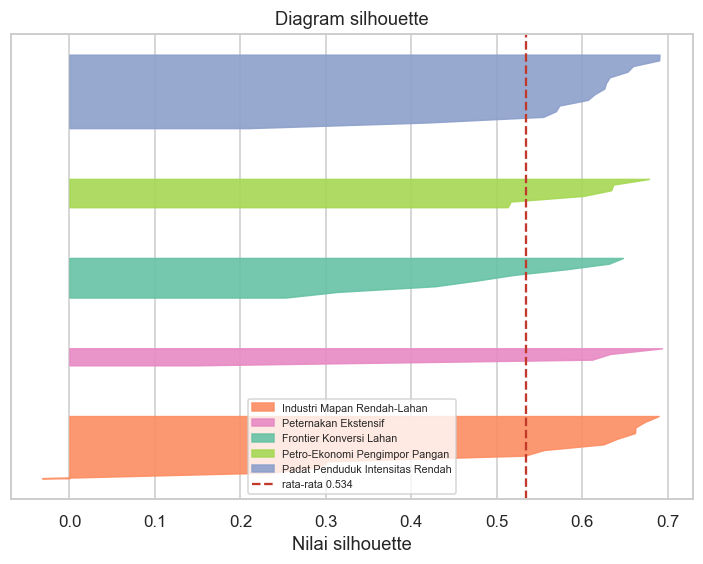

silhouette negatif: ['Lebanon']


In [14]:
sil = silhouette_samples(Z, lab)
fig, ax = plt.subplots(figsize=(8,5.5)); y0 = 10
for k in sorted(set(lab)):
    v = np.sort(sil[lab==k]); y1 = y0+len(v)
    ax.fill_betweenx(np.arange(y0,y1), 0, v, color=warna[NAMA[k]], alpha=.9, label=NAMA[k])
    y0 = y1+8
ax.axvline(sil.mean(), color=BATA, ls='--', label=f'rata-rata {sil.mean():.3f}')
ax.set(xlabel='Nilai silhouette', yticks=[], title='Diagram silhouette')
ax.legend(fontsize=7); plt.savefig('gambar/02_silhouette.svg'); plt.show()
print('silhouette negatif:', [c for c,s in zip(NEG,sil) if s<0] or 'tidak ada')

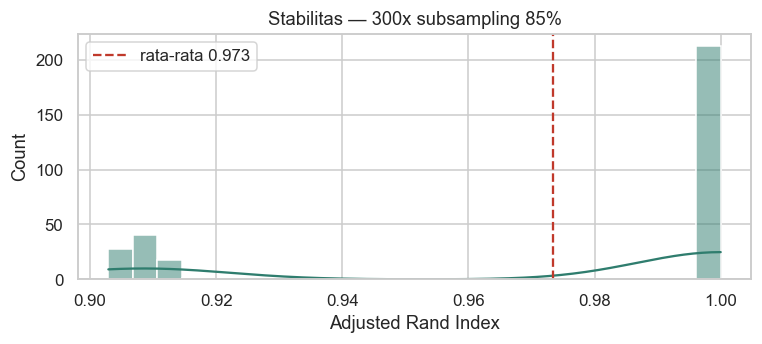

ARI 0.973 +/- 0.042 | minimum 0.903


,KMeans,Ward,GMM,Average
KMeans,1.000,0.851,0.573,0.588
Ward,0.851,1.000,0.573,0.588
GMM,0.573,0.573,1.000,0.976
Average,0.588,0.588,0.976,1.000


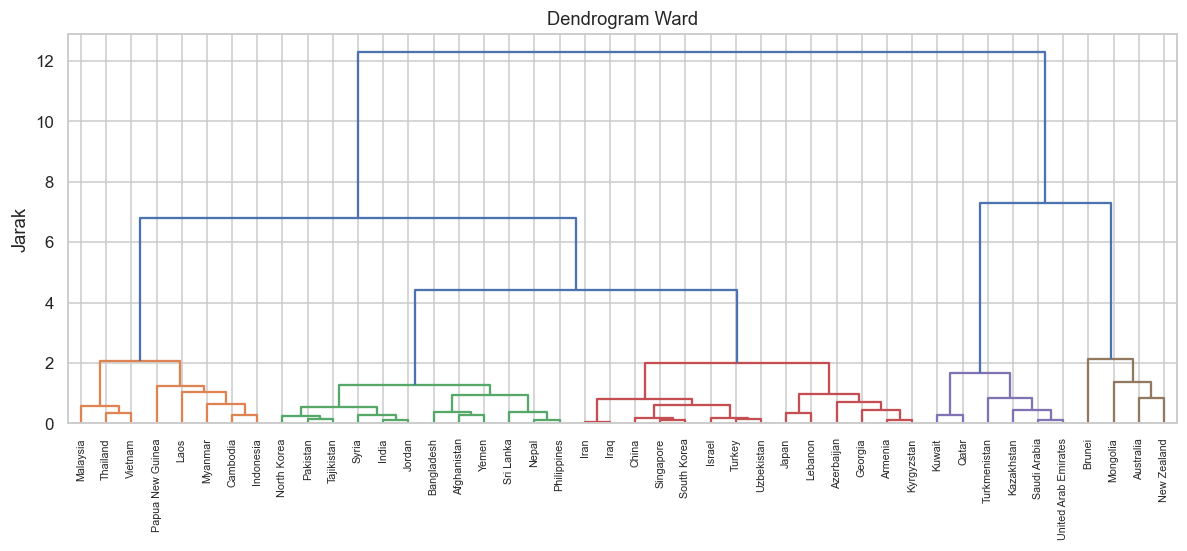

In [15]:
rng = np.random.default_rng(RS); ari = []
for _ in range(300):
    idx = rng.choice(N, int(N*.85), replace=False)
    ari.append(adjusted_rand_score(lab[idx], KMeans(K, n_init=50, random_state=RS).fit_predict(Z[idx])))
ari = np.array(ari)
plt.figure(figsize=(7,3.2)); sns.histplot(ari, bins=25, kde=True, color=HIJAU)
plt.axvline(ari.mean(), color=BATA, ls='--', label=f'rata-rata {ari.mean():.3f}')
plt.xlabel('Adjusted Rand Index'); plt.title('Stabilitas — 300x subsampling 85%')
plt.legend(); plt.tight_layout(); plt.show()
print(f'ARI {ari.mean():.3f} +/- {ari.std():.3f} | minimum {ari.min():.3f}')

def bangun(a,k,Zz):
    return algoritma(a,k,Zz)
alg = {a: bangun(a,K,Z) for a in ['KMeans','Ward','GMM','Average']}
display(pd.DataFrame({a:[adjusted_rand_score(alg[a],alg[b]) for b in alg]
                      for a in alg}, index=list(alg)).round(3))

L = linkage(Z, method='ward')
plt.figure(figsize=(13,4.6))
dendrogram(L, labels=np.array(NEG), leaf_rotation=90, leaf_font_size=7, color_threshold=L[-(K-1),2])
plt.title('Dendrogram Ward'); plt.ylabel('Jarak')
plt.savefig('gambar/06_dendrogram.svg'); plt.show()

### 6b. Kesepakatan antarruang fitur — pembuktian bahwa panel tidak boleh direduksi

In [16]:
Z_traj = PCA(2, random_state=RS).fit_transform(StandardScaler().fit_transform(X_traj))
Z_seri = PCA(2, random_state=RS).fit_transform(StandardScaler().fit_transform(X_seri))
l_traj = KMeans(6, n_init=200, random_state=RS).fit_predict(Z_traj)
l_seri = KMeans(6, n_init=200, random_state=RS).fit_predict(Z_seri)
print(f'POTRET  vs LINTASAN : ARI = {adjusted_rand_score(lab, l_traj):.3f}')
print(f'POTRET  vs SERI     : ARI = {adjusted_rand_score(lab, l_seri):.3f}')
print(f'LINTASAN vs SERI    : ARI = {adjusted_rand_score(l_traj, l_seri):.3f}')
print('\nARI rendah => tipologi berdasarkan LINTASAN berbeda nyata dari tipologi berdasarkan')
print('POTRET, artinya dimensi waktu memuat informasi yang hilang bila panel direduksi satu tahun.')

POTRET  vs LINTASAN : ARI = 0.173
POTRET  vs SERI     : ARI = 0.055
LINTASAN vs SERI    : ARI = 0.143

ARI rendah => tipologi berdasarkan LINTASAN berbeda nyata dari tipologi berdasarkan
POTRET, artinya dimensi waktu memuat informasi yang hilang bila panel direduksi satu tahun.


## 7. Kestabilan Klaster Lintas Dekade

In [17]:
PER = [(1961,1970),(1971,1980),(1981,1990),(1991,2000),(2001,2010),(2011,2020)]
ref, jalur = None, {}
for a,b in PER:
    pp = panel[panel.year.between(a,b)].groupby('country')[V].mean().loc[NEG]
    Mx = StandardScaler().fit_transform(np.column_stack([np.log1p(pp[v].clip(lower=0)) for v in V]))
    Zp = PCA(2, random_state=RS).fit_transform(Mx)
    km = KMeans(K, n_init=200, random_state=RS).fit(Zp); lp = km.labels_
    if ref is None: ref = km.cluster_centers_
    else:
        C = np.linalg.norm(km.cluster_centers_[:,None,:]-ref[None,:,:], axis=2)
        r,c = linear_sum_assignment(C); m = dict(zip(r,c)); lp = np.array([m[x] for x in lp])
    jalur[f'{str(a)[2:]}-{str(b)[2:]}'] = lp
jl = pd.DataFrame(jalur, index=NEG)
display(jl.loc[ASEAN])
pin = pd.Series((jl.values[:,1:]!=jl.values[:,:-1]).sum(1), index=NEG).loc[ASEAN]
print(f'perpindahan rata-rata: {pin.mean():.2f} dari 5 transisi')
print('tidak pernah pindah  :', sorted(pin[pin==0].index.tolist()))

,61-70,71-80,81-90,91-00,01-10,11-20
Brunei,2,3,3,2,3,3
Cambodia,4,1,4,4,4,4
Indonesia,4,4,4,4,4,4
Laos,4,4,4,4,4,4
Malaysia,4,4,4,4,4,4
Myanmar,4,4,1,4,4,4
Philippines,4,4,1,1,1,1
Singapore,2,2,2,2,2,2
Thailand,4,4,4,1,4,2
Vietnam,1,1,1,4,4,4


perpindahan rata-rata: 1.20 dari 5 transisi
tidak pernah pindah  : ['Indonesia', 'Laos', 'Malaysia', 'Singapore']


## 8. Indeks Komposit — Tiga Sudut Pandang

Satu indeks tidak cukup. Intensitas per kapita dan kontribusi absolut menceritakan hal yang
berbeda, dan perbedaan itu sendiri adalah temuan.

In [18]:
mm = lambda s: (s-s.min())/(s.max()-s.min())
norm = pd.DataFrame({v: mm(np.log1p(potret[v].clip(lower=0))) for v in V}, index=NEG)
w1 = np.abs(P2.components_[0]); B1 = pd.Series(w1/w1.sum(), index=V)
print('Bobot dari PC1:'); print(B1.rename(LAB).round(4).to_string())

potret['idx_intensitas']     = (norm*B1).sum(axis=1)
B2 = pd.Series([.55,.20,.15,.10], index=V)
potret['idx_konversi_lahan'] = (norm*(B2/B2.sum())).sum(axis=1)

for kol, jud in [('idx_intensitas','A. Intensitas emisi sistem pangan per kapita'),
                 ('idx_konversi_lahan','B. Tekanan konversi lahan'),
                 ('pangsa_global_luc','C. Pangsa emisi lahan global 2024 (%)')]:
    if kol not in potret: continue
    print(f'\n{jud}')
    for c,v_ in potret[kol].sort_values(ascending=False).head(8).items():
        print(f'   {c:<22}{v_:8.3f}{"   <-- ASEAN" if c in ASEAN else ""}')
display(potret[['idx_intensitas','idx_konversi_lahan']].corr('spearman').round(3))

Bobot dari PC1:
CO2 lahan     0.1141
Metana        0.3269
N2O           0.2908
CO2 energi    0.2682

A. Intensitas emisi sistem pangan per kapita
   Mongolia                 0.852
   Australia                0.753
   New Zealand              0.748
   Brunei                   0.644   <-- ASEAN
   Qatar                    0.587
   Kuwait                   0.559
   Turkmenistan             0.471
   Saudi Arabia             0.447

B. Tekanan konversi lahan
   New Zealand              0.833
   Australia                0.737
   Mongolia                 0.674
   Laos                     0.666   <-- ASEAN
   Brunei                   0.664   <-- ASEAN
   Indonesia                0.559   <-- ASEAN
   Papua New Guinea         0.543
   Malaysia                 0.540   <-- ASEAN

C. Pangsa emisi lahan global 2024 (%)
   Indonesia               12.565   <-- ASEAN
   Vietnam                  2.469   <-- ASEAN
   Thailand                 2.448   <-- ASEAN
   Myanmar                  1.620   <-- ASEAN


,idx_intensitas,idx_konversi_lahan
idx_intensitas,1.000,0.774
idx_konversi_lahan,0.774,1.000


## 9. Bobot Spasial

Negara Asia terpisah laut dan selat, sehingga bobot ketetanggaan biasa menghasilkan unit
terisolasi (Singapura, Brunei, Filipina, Jepang). Dipakai k-tetangga-terdekat atas koordinat
ibu kota, dengan k dipilih berdasarkan kekuatan ketergantungan spasial pada residual OLS.

In [19]:
def moran(x, W, perms=999, seed=RS):
    x = np.asarray(x, float); z = x - x.mean()
    I = (z @ (W @ z)) / (z @ z)
    rng = np.random.default_rng(seed); c = 0
    for _ in range(perms):
        zp = rng.permutation(z)
        if abs((zp @ (W @ zp))/(zp @ zp)) >= abs(I): c += 1
    return I, -1/(len(x)-1), (c+1)/(perms+1)

def ols(y, X):
    b, *_ = np.linalg.lstsq(X, y, rcond=None); e = y - X@b
    V = ((e@e)/(len(y)-X.shape[1])) * np.linalg.pinv(X.T@X)
    return b, np.sqrt(np.diag(V)), e, 1-(e@e)/(((y-y.mean())**2).sum())

Wk = lambda k: pd.read_csv(f'{DIR}/W_knn{k}_asia44.csv', index_col=0).loc[NEG,NEG].values
s24 = panel[panel.year==2024].set_index('country').loc[NEG]
X24 = np.column_stack([np.ones(N)] + [s24[c].values for c in X_])
_,_,e24,_ = ols(s24[Y_].values, X24)
tb = pd.DataFrame([{'k':k, **dict(zip(['Moran I residual','E[I]','p'], moran(e24, Wk(k))))}
                   for k in range(3,9)]).round(4)
display(tb)
K_OPT = int(tb.loc[tb['Moran I residual'].idxmax(),'k'])
W = Wk(K_OPT); lam = np.linalg.eigvals(W).real
print(f'k terpilih = {K_OPT}')

,k,Moran I residual,E[I],p
0,3,0.6628,-0.0233,0.001
1,4,0.7029,-0.0233,0.001
2,5,0.6588,-0.0233,0.001
3,6,0.6350,-0.0233,0.001
4,7,0.6173,-0.0233,0.001
5,8,0.6071,-0.0233,0.001


k terpilih = 4


## 10. Autokorelasi Spasial

,variabel,Moran's I,E[I],p
0,log CO2 lahan/kap,0.7285,-0.0233,0.001
1,log Metana/kap,0.2517,-0.0233,0.007
2,log N2O/kap,0.1117,-0.0233,0.185
3,log CO2 energi/kap,0.3628,-0.0233,0.003


,tahun,Moran's I,E[I],p
0,1961,0.2552,-0.0233,0.012
1,1968,0.4098,-0.0233,0.002
2,1975,0.4983,-0.0233,0.002
3,1982,0.3862,-0.0233,0.004
4,1989,0.4721,-0.0233,0.002
5,1996,0.5507,-0.0233,0.002
6,2003,0.5926,-0.0233,0.002
7,2010,0.5394,-0.0233,0.002
8,2017,0.6007,-0.0233,0.002
9,2024,0.7285,-0.0233,0.002


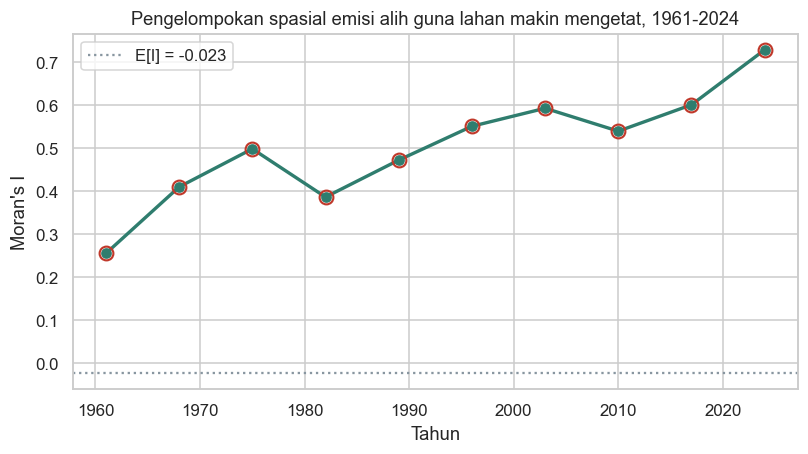

In [20]:
display(pd.DataFrame([{'variabel':nm, **dict(zip(["Moran's I",'E[I]','p'], moran(s24[c].values, W)))}
                      for c,nm in zip([Y_]+X_, ['log CO2 lahan/kap']+NAMA_X)]).round(4))

tren = [{'tahun':yr, **dict(zip(["Moran's I",'E[I]','p'],
        moran(panel[panel.year==yr].set_index('country').loc[NEG,Y_].values, W, perms=499)))}
        for yr in range(1961,2025,7)]
tI = pd.DataFrame(tren).round(4); display(tI)

fig, ax = plt.subplots(figsize=(8.5,4.2))
ax.plot(tI.tahun, tI["Moran's I"], marker='o', color=HIJAU, lw=2.2)
ax.axhline(-1/(N-1), color=ABU, ls=':', label=f'E[I] = {-1/(N-1):.3f}')
for _,r in tI.iterrows():
    if r['p']<.05: ax.plot(r.tahun, r["Moran's I"], marker='o', ms=9, mfc='none', mec=BATA, mew=1.4)
ax.set(xlabel='Tahun', ylabel="Moran's I",
       title='Pengelompokan spasial emisi alih guna lahan makin mengetat, 1961-2024')
ax.legend(); plt.savefig('gambar/03_moran_lintasan.svg'); plt.show()

In [21]:
def lisa_lokal(x, W, perms=999, seed=RS):
    z = x - x.mean(); m2 = (z@z)/len(z); Wz = W@z; Ii = z*Wz/m2
    rng = np.random.default_rng(seed); n = len(z); cnt = np.zeros(n)
    for _ in range(perms):
        for i in range(n):
            idx = [j for j in range(n) if j != i]
            zp = rng.permutation(z[idx])
            if abs(z[i]*(W[i,idx]@zp)/m2) >= abs(Ii[i]): cnt[i] += 1
    q = np.where((z>0)&(Wz>0),'High-High', np.where((z<0)&(Wz<0),'Low-Low',
        np.where((z>0)&(Wz<0),'High-Low','Low-High')))
    return Ii, (cnt+1)/(perms+1), q, z, Wz

Ii, p_l, q_l, z_l, Wz_l = lisa_lokal(s24[Y_].values, W, perms=499)
lisa = pd.DataFrame({'country':NEG,'z':z_l,'Wz':Wz_l,'Ii':Ii,'p':p_l,'kuadran':q_l})
lisa['lisa'] = np.where(lisa.p<.05, lisa.kuadran, 'Tidak signifikan')
lisa['ASEAN'] = lisa.country.isin(ASEAN)
print(lisa.lisa.value_counts().to_string())
for kat in ['High-High','Low-Low','High-Low','Low-High']:
    a = lisa[lisa.lisa==kat]
    if len(a): print(f'\n{kat} (n={len(a)}): {", ".join(a.country)}')
print(f'\n>>> {lisa[(lisa.ASEAN)&(lisa.lisa=="High-High")].shape[0]} dari 10 negara ASEAN High-High')

lisa
Tidak signifikan    32
High-High           10
Low-High             2

High-High (n=10): Australia, Cambodia, Indonesia, Laos, Malaysia, Myanmar, New Zealand, Papua New Guinea, Thailand, Vietnam

Low-High (n=2): Philippines, Singapore

>>> 7 dari 10 negara ASEAN High-High


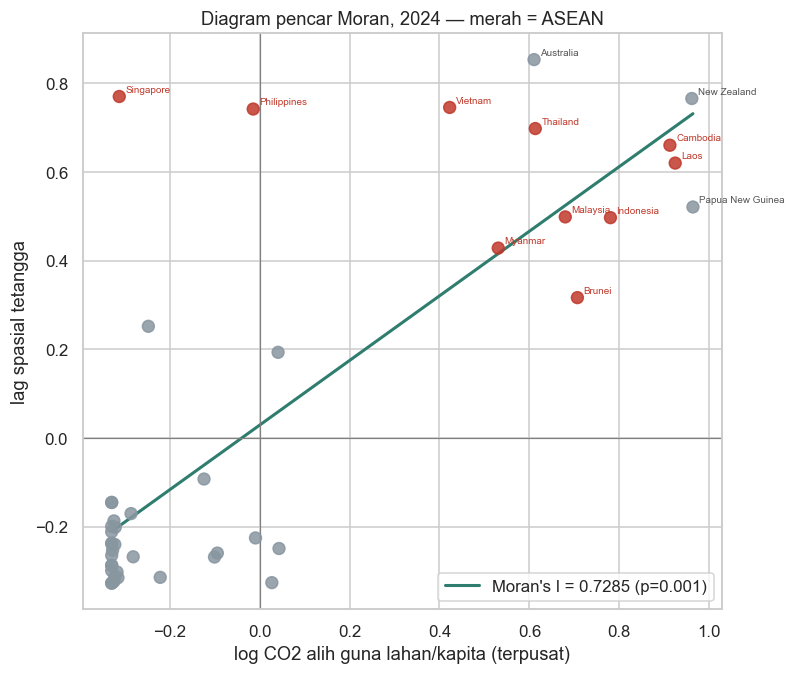

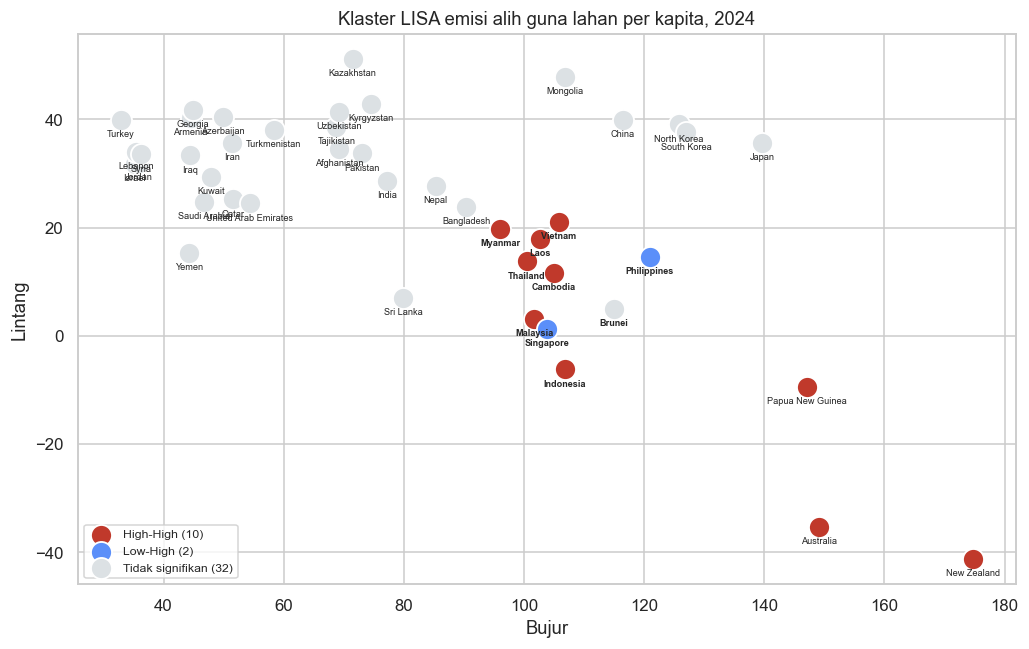

In [22]:
fig, ax = plt.subplots(figsize=(7.5,6.8))
ax.scatter(z_l, Wz_l, s=60, c=[BATA if a else ABU for a in lisa.ASEAN], alpha=.85, zorder=3)
bb, aa = np.polyfit(z_l, Wz_l, 1); xx = np.linspace(z_l.min(), z_l.max(), 50)
I0,_,p0 = moran(s24[Y_].values, W)
ax.plot(xx, aa+bb*xx, color=HIJAU, lw=2, label=f"Moran's I = {I0:.4f} (p={p0:.3f})")
ax.axhline(0, color='grey', lw=.8); ax.axvline(0, color='grey', lw=.8)
for i,c in enumerate(NEG):
    if abs(z_l[i])>.8 or abs(Wz_l[i])>.8 or c in ASEAN:
        ax.annotate(c, (z_l[i],Wz_l[i]), fontsize=6.5, xytext=(4,3), textcoords='offset points',
                    color=BATA if c in ASEAN else '#555')
ax.set(xlabel='log CO2 alih guna lahan/kapita (terpusat)', ylabel='lag spasial tetangga',
       title='Diagram pencar Moran, 2024 — merah = ASEAN')
ax.legend(); plt.savefig('gambar/04_pencar_moran.svg'); plt.show()

wl = {'High-High':BATA,'Low-High':'#5B8FF9','Low-Low':HIJAU,'High-Low':PASIR,
      'Tidak signifikan':'#DCE1E4'}
kk = koord.set_index('country').loc[NEG]
fig, ax = plt.subplots(figsize=(11,6.5))
for kat,col in wl.items():
    m = (lisa.lisa==kat).values
    if m.sum()==0: continue
    ax.scatter(kk.lon.values[m], kk.lat.values[m], s=190, c=col, edgecolor='white',
               lw=1.2, label=f'{kat} ({m.sum()})', zorder=3)
for i,c in enumerate(NEG):
    ax.annotate(c, (kk.lon.iloc[i],kk.lat.iloc[i]), fontsize=6, xytext=(0,-11), ha='center',
                textcoords='offset points', weight='bold' if c in ASEAN else 'normal')
ax.set(xlabel='Bujur', ylabel='Lintang', title='Klaster LISA emisi alih guna lahan per kapita, 2024')
ax.legend(fontsize=8, loc='lower left'); plt.savefig('gambar/05_peta_lisa.svg'); plt.show()

## 11. Model Panel Spasial

Lima spesifikasi dibandingkan pada dua skema efek tetap.

**Catatan metodologis penting.** Pada efek tetap **dua arah** (negara + waktu), seluruh suku
spasial runtuh (ρ ≈ 0,02; LR = 0,5). Sebabnya, efek tetap negara menyerap justru variasi
antarnegara yang merupakan sinyal spasial itu sendiri — dan Bagian 2 menunjukkan 76–93% ragam
memang bersifat antar-negara. Karena itu spesifikasi utama memakai **efek tetap waktu saja**,
dan pilihan ini wajib dinyatakan terbuka di naskah, bukan didiamkan.

In [23]:
piv = lambda c: panel.pivot(index='year', columns='country', values=c)[NEG].values
dt   = lambda M: M - M.mean(1, keepdims=True)
dtw  = lambda M: M - M.mean(1,keepdims=True) - M.mean(0,keepdims=True) + M.mean()
Y, Xl = piv(Y_), [piv(c) for c in X_]

def ll_sar(rho, yv, X, wy):
    ey = yv - rho*wy; b,*_ = np.linalg.lstsq(X, ey, rcond=None); e = ey - X@b
    return (-(N*T/2)*(np.log(2*np.pi)+1) - (N*T/2)*np.log((e@e)/(N*T))
            + T*np.sum(np.log(np.abs(1-rho*lam))), b, e)

def ll_sem(lmb, yv, X):
    Ym = yv.reshape(T,N); Xm = [X[:,j].reshape(T,N) for j in range(X.shape[1])]
    yt = (Ym - lmb*(Ym@W.T)).ravel()
    Xt = np.column_stack([(x - lmb*(x@W.T)).ravel() for x in Xm])
    b,*_ = np.linalg.lstsq(Xt, yt, rcond=None); e = yt - Xt@b
    return (-(N*T/2)*(np.log(2*np.pi)+1) - (N*T/2)*np.log((e@e)/(N*T))
            + T*np.sum(np.log(np.abs(1-lmb*lam))), b, e)

grid_r = np.linspace(-.95,.95,391); aic = lambda ll,k: -2*ll+2*k
for tag, dem in [('Efek tetap WAKTU', dt), ('Efek tetap DUA ARAH', dtw)]:
    yv = dem(Y).ravel()
    Xv = np.column_stack([dem(x).ravel() for x in Xl])
    WX = np.column_stack([dem(x@W.T).ravel() for x in Xl])
    XD = np.column_stack([Xv, WX]); wy = dem(Y@W.T).ravel()
    b,se,e,r2 = ols(yv,Xv); ll0 = -(N*T/2)*(np.log(2*np.pi)+1)-(N*T/2)*np.log((e@e)/(N*T))
    bX,seX,eX,r2X = ols(yv,XD); llX = -(N*T/2)*(np.log(2*np.pi)+1)-(N*T/2)*np.log((eX@eX)/(N*T))
    rho = grid_r[int(np.argmax([ll_sar(r,yv,Xv,wy)[0] for r in grid_r]))]
    llS,bS,eS = ll_sar(rho,yv,Xv,wy)
    lmb = grid_r[int(np.argmax([ll_sem(l,yv,Xv)[0] for l in grid_r]))]
    llE,bE,eE = ll_sem(lmb,yv,Xv)
    rhoD = grid_r[int(np.argmax([ll_sar(r,yv,XD,wy)[0] for r in grid_r]))]
    llD,bD,eD = ll_sar(rhoD,yv,XD,wy)
    R2 = lambda ee: 1-(ee@ee)/(((yv-yv.mean())**2).sum())
    print(f'\n--- {tag} ---')
    display(pd.DataFrame([
      {'Model':'OLS','par':Xv.shape[1],  'logLik':ll0,'AIC':aic(ll0,Xv.shape[1]),  'rho/lambda':np.nan,'R2':r2},
      {'Model':'SLX','par':XD.shape[1],  'logLik':llX,'AIC':aic(llX,XD.shape[1]),  'rho/lambda':np.nan,'R2':r2X},
      {'Model':'SAR','par':Xv.shape[1]+1,'logLik':llS,'AIC':aic(llS,Xv.shape[1]+1),'rho/lambda':rho, 'R2':R2(eS)},
      {'Model':'SEM','par':Xv.shape[1]+1,'logLik':llE,'AIC':aic(llE,Xv.shape[1]+1),'rho/lambda':lmb, 'R2':R2(eE)},
      {'Model':'SDM','par':XD.shape[1]+1,'logLik':llD,'AIC':aic(llD,XD.shape[1]+1),'rho/lambda':rhoD,'R2':R2(eD)},
    ]).round(3))
    print(f'LR  SAR vs OLS {2*(llS-ll0):8.2f} | SEM vs OLS {2*(llE-ll0):8.2f} | '
          f'SDM vs SAR {2*(llD-llS):8.2f}   (khi-kuadrat 5% = 3,84)')
    if tag.endswith('WAKTU'): simpan = (rhoD, bD, eD, XD, yv, wy)


--- Efek tetap WAKTU ---


,Model,par,logLik,AIC,rho/lambda,R2
0,OLS,3,-2812.164,5630.327,NaN,0.243
1,SLX,6,-2712.783,5437.567,NaN,0.294
2,SAR,4,-2420.395,4848.791,0.507,0.460
3,SEM,4,-2414.361,4836.723,0.551,0.469
4,SDM,7,-2369.024,4752.047,0.516,0.481


LR  SAR vs OLS   783.54 | SEM vs OLS   795.60 | SDM vs SAR   102.74   (khi-kuadrat 5% = 3,84)

--- Efek tetap DUA ARAH ---


,Model,par,logLik,AIC,rho/lambda,R2
0,OLS,3,-968.208,1942.416,NaN,0.017
1,SLX,6,-937.944,1887.887,NaN,0.038
2,SAR,4,-967.945,1943.890,0.019,0.017
3,SEM,4,-967.126,1942.252,0.044,0.018
4,SDM,7,-937.516,1889.032,0.029,0.038


LR  SAR vs OLS     0.53 | SEM vs OLS     2.16 | SDM vs SAR    60.86   (khi-kuadrat 5% = 3,84)


## 12. Model Terpilih dan Dekomposisi Efek LeSage–Pace

SDM panel, efek tetap waktu | rho = +0.5164 | N x T = 2816



,variabel,koefisien,se,t,sig
0,log Metana/kap,0.3694,0.0234,15.7725,***
1,log N2O/kap,0.4179,0.0348,12.0185,***
2,log CO2 energi/kap,-0.3093,0.0166,-18.6296,***
3,W x log Metana/kap,-0.3342,0.0382,-8.7436,***
4,W x log N2O/kap,0.3586,0.0980,3.6608,***
5,W x log CO2 energi/kap,0.1299,0.0286,4.5488,***


,variabel,langsung,tak langsung,total
0,log Metana/kap,0.3486,-0.2759,0.0727
1,log N2O/kap,0.5011,1.1046,1.6057
2,log CO2 energi/kap,-0.3137,-0.0573,-0.3710


Catatan: pangsa limpahan dalam persen tidak dilaporkan untuk metana karena efek total
mendekati nol (0,07) sehingga rasionya tidak stabil; tafsirkan nilai mutlaknya.


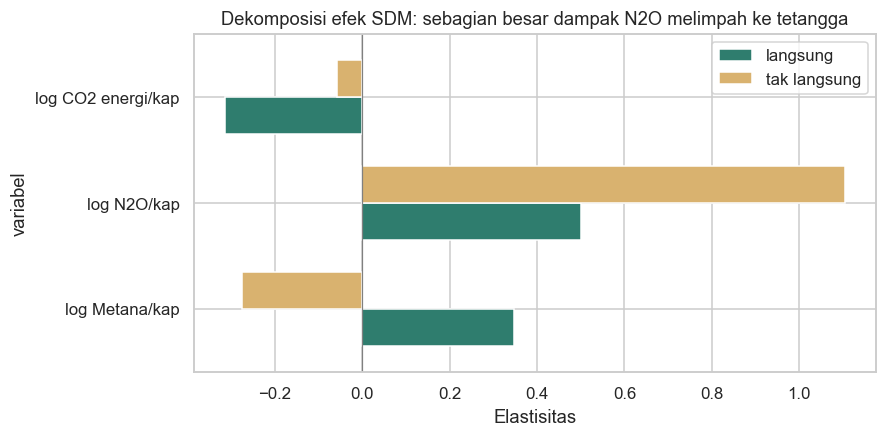


Moran I residual signifikan pada 2/64 tahun (3%)


In [24]:
rhoD, bD, eD, XD, yv, wy = simpan
dof = N*T - XD.shape[1] - T
se = np.sqrt(np.diag(((eD@eD)/dof)*np.linalg.pinv(XD.T@XD))); tt = bD/se
print(f'SDM panel, efek tetap waktu | rho = {rhoD:+.4f} | N x T = {N*T}\n')
display(pd.DataFrame({'variabel':NAMA_X+['W x '+n for n in NAMA_X],
                      'koefisien':bD, 'se':se, 't':tt,
                      'sig':['***' if abs(x)>2.58 else '**' if abs(x)>1.96
                             else '*' if abs(x)>1.64 else '' for x in tt]}).round(4))

S0 = np.linalg.inv(np.eye(N) - rhoD*W); rek = []
for i,nm in enumerate(NAMA_X):
    Sk = S0 @ (bD[i]*np.eye(N) + bD[i+3]*W)
    lang = np.mean(np.diag(Sk)); tot = Sk.sum()/N
    rek.append({'variabel':nm,'langsung':lang,'tak langsung':tot-lang,'total':tot})
ef = pd.DataFrame(rek); display(ef.round(4))
print('Catatan: pangsa limpahan dalam persen tidak dilaporkan untuk metana karena efek total')
print('mendekati nol (0,07) sehingga rasionya tidak stabil; tafsirkan nilai mutlaknya.')

fig, ax = plt.subplots(figsize=(8,4))
ef.set_index('variabel')[['langsung','tak langsung']].plot(kind='barh', ax=ax,
                                                           color=[HIJAU,PASIR], width=.7)
ax.axvline(0, color='grey', lw=.8); ax.set(xlabel='Elastisitas',
       title='Dekomposisi efek SDM: sebagian besar dampak N2O melimpah ke tetangga')
plt.savefig('gambar/08_dekomposisi_efek.svg'); plt.show()

res = eD.reshape(T,N)
sig = sum(1 for i in range(T) if moran(res[i], W, perms=299)[2] < .05)
print(f'\nMoran I residual signifikan pada {sig}/{T} tahun ({100*sig/T:.0f}%)')

## 13. Ketegaran: Sampel Asia Monsun-19

In [25]:
mon = [c for c in NEG if c in MONSUN]; Nm = len(mon)
Wm = pd.read_csv(f'{DIR}/W_knn5_monsun{Nm}.csv', index_col=0).loc[mon,mon].values
lm_ = np.linalg.eigvals(Wm).real
pm = panel[panel.country.isin(mon)]
pv = lambda c: pm.pivot(index='year', columns='country', values=c)[mon].values
Ym = pv(Y_); Xm = [pv(c) for c in X_]
dm = lambda M: M - M.mean(1, keepdims=True)
yvm = dm(Ym).ravel(); Xvm = np.column_stack([dm(x).ravel() for x in Xm]); wym = dm(Ym@Wm.T).ravel()
def llm(r):
    ey = yvm-r*wym; b,*_ = np.linalg.lstsq(Xvm,ey,rcond=None); e = ey-Xvm@b
    return (-(Nm*T/2)*(np.log(2*np.pi)+1)-(Nm*T/2)*np.log((e@e)/(Nm*T))
            + T*np.sum(np.log(np.abs(1-r*lm_))))
rm = grid_r[int(np.argmax([llm(r) for r in grid_r]))]
b0m,*_ = np.linalg.lstsq(Xvm,yvm,rcond=None); e0m = yvm-Xvm@b0m
ll0m = -(Nm*T/2)*(np.log(2*np.pi)+1)-(Nm*T/2)*np.log((e0m@e0m)/(Nm*T))
print(f'n = {Nm} | rho = {rm:+.4f} | LR vs OLS = {2*(llm(rm)-ll0m):.1f}')
Im,EIm,pmv = moran(pm[pm.year==2024].set_index('country').loc[mon,Y_].values, Wm)
print(f"Moran's I 2024 = {Im:+.4f} (E[I] = {EIm:+.3f}, p = {pmv:.3f})")

lab_m = KMeans(4, n_init=300, random_state=RS).fit_predict(
    PCA(2, random_state=RS).fit_transform(StandardScaler().fit_transform(
        np.column_stack([np.log1p(potret.loc[mon,v].clip(lower=0)) for v in V]))))
a44 = pd.Series(lab, index=NEG).loc[ASEAN].values
aMS = pd.Series(lab_m, index=mon).loc[ASEAN].values
print(f'\nARI tipologi ASEAN, Asia-44 vs Monsun-19 = {adjusted_rand_score(a44,aMS):.3f}')
print('ARI = 1,000 berarti perluasan sampel demi kesahihan spasial tidak menggeser cerita ASEAN.')

n = 19 | rho = +0.3751 | LR vs OLS = 89.9
Moran's I 2024 = +0.3460 (E[I] = -0.056, p = 0.003)

ARI tipologi ASEAN, Asia-44 vs Monsun-19 = 1.000
ARI = 1,000 berarti perluasan sampel demi kesahihan spasial tidak menggeser cerita ASEAN.


## 14. Pembanding dengan libpysal/spreg (opsional)

Sel di bawah hanya berjalan bila paket ekonometrika spasial terpasang. Fungsinya memverifikasi
bahwa implementasi numpy di atas menghasilkan angka yang sama.

In [26]:
try:
    from libpysal.weights import KNN
    from esda.moran import Moran, Moran_Local
    from spreg import OLS as spOLS, ML_Lag, ML_Error
    kd = koord.set_index('country').loc[NEG]
    wk = KNN.from_array(kd[['lon','lat']].values, k=K_OPT); wk.transform = 'r'
    mi = Moran(s24[Y_].values, wk, permutations=999)
    print(f"esda Moran's I = {mi.I:.4f} (p = {mi.p_sim:.4f})")
    print(f"numpy Moran's I = {moran(s24[Y_].values, W)[0]:.4f}")
except ImportError:
    print('libpysal/esda/spreg tidak terpasang — lewati pembanding.')

esda Moran's I = 0.7154 (p = 0.0010)
numpy Moran's I = 0.7285
